# EDA on Retail Sales Data — Superstore Dataset
**Author:** Minhaj Uddin Farhad
**Track:** Data Analytics (OIBSIP)
**Task:** Level 1 — EDA on Retail Sales Data

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

## Step 1: Import Libraries and Load the Data

We start by importing the tools we need:
- `pandas` — for loading and manipulating the data (tables)
- `matplotlib` and `seaborn` — for making charts
- We also set some display options so pandas doesn't truncate our output.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


**Note on `encoding='latin1'`:** This file has some special characters (city/state names) that aren't standard UTF-8, so we tell pandas to read it as latin1 to avoid errors.

## Step 2: Initial Inspection

Feature checklist requires: shape, column dtypes, and a null value check. This tells us how big the dataset is, what type of data each column holds, and whether any values are missing.

In [2]:
# Shape of the dataset
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()

# Column data types
print("Column data types:")
print(df.dtypes)

Dataset shape: 9994 rows, 21 columns

Column data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [3]:
# Null value check
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


**Observation:** *(Write your own version of this in your own words for the video/README)*

The dataset has 9,994 rows and 21 columns, with no missing values in any column — so no cleaning is needed for nulls. The columns cover order details (dates, ship mode), customer details (ID, name, segment, location), product details (category, sub-category, name), and the key numeric metrics we'll analyze: Sales, Quantity, Discount, and Profit.

## Step 3: Descriptive Statistics

Now we look at the numerical columns — Sales, Quantity, Discount, Profit — and get their mean, median, mode, and standard deviation. This tells us the "typical" order size and how much values vary.

In [4]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

desc_stats = df[numeric_cols].describe()
print("Descriptive statistics (from .describe()):")
print(desc_stats)
print()

# Mode isn't included in .describe(), so we add it separately
print("Mode (most frequent value) for each column:")
for col in numeric_cols:
    print(f"  {col}: {df[col].mode()[0]}")

Descriptive statistics (from .describe()):
              Sales     Quantity     Discount       Profit
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574     0.156203    28.656896
std      623.245101     2.225110     0.206452   234.260108
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.728750
50%       54.490000     3.000000     0.200000     8.666500
75%      209.940000     5.000000     0.200000    29.364000
max    22638.480000    14.000000     0.800000  8399.976000

Mode (most frequent value) for each column:
  Sales: 12.96
  Quantity: 3
  Discount: 0.0
  Profit: 0.0


**Observation:** *(write your own take)*

Average Sales per line item is around \$230, but the standard deviation is large relative to the mean — meaning most orders are small, with a few large outlier orders pulling the average up. Discount is mostly 0 (mode), meaning most items sell at full price. Profit can be negative (loss-making sales after discount), which is worth investigating further.

## Step 4: Time Series Analysis — Monthly and Quarterly Sales Trends

First we convert `Order Date` from text to an actual datetime type, so pandas can group by month/quarter. Then we plot how Sales change over time.

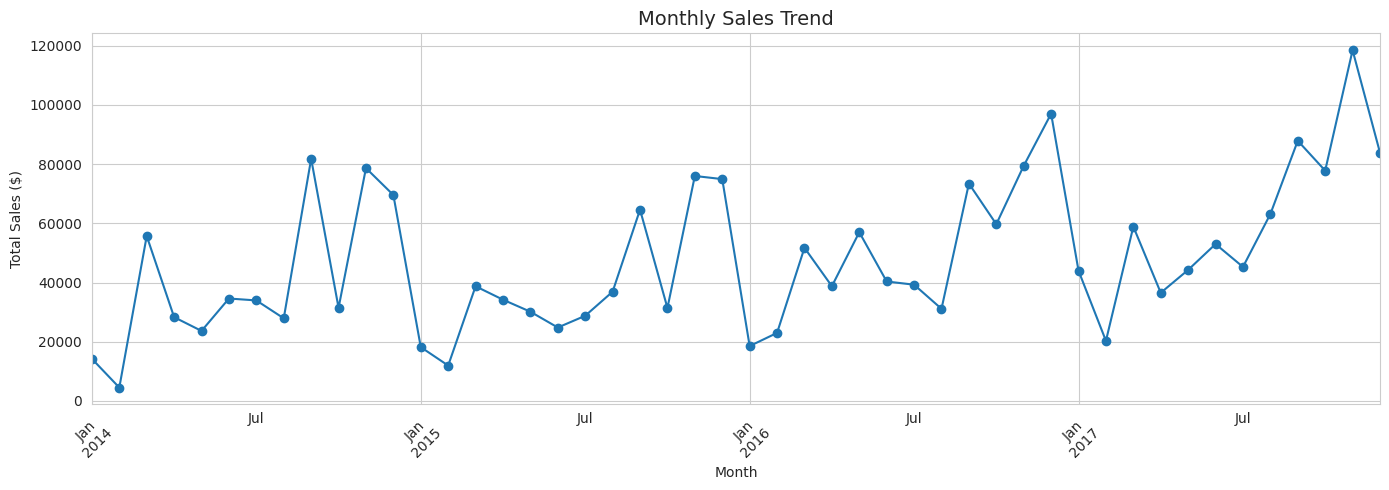

In [5]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Year-Month and Year-Quarter columns
df['YearMonth'] = df['Order Date'].dt.to_period('M')
df['YearQuarter'] = df['Order Date'].dt.to_period('Q')

# Monthly sales trend
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(kind='line', marker='o', color='#1f77b4')
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

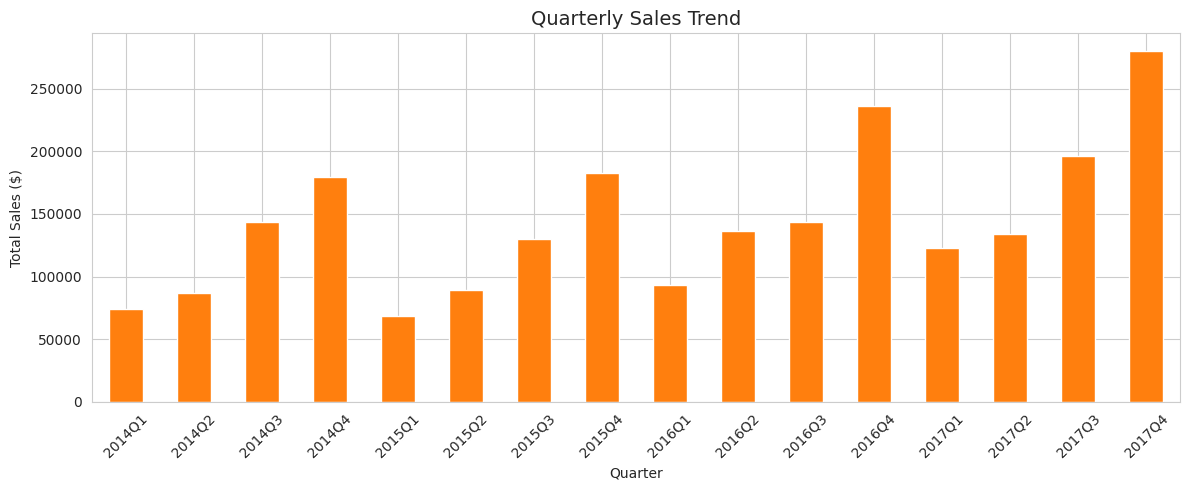

In [6]:
# Quarterly sales trend
quarterly_sales = df.groupby('YearQuarter')['Sales'].sum()

plt.figure(figsize=(12, 5))
quarterly_sales.plot(kind='bar', color='#ff7f0e')
plt.title('Quarterly Sales Trend', fontsize=14)
plt.xlabel('Quarter')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:** *(write your own take)*

Sales show a clear seasonal pattern — there's usually a spike toward the end of each year (Nov–Dec), likely due to holiday shopping. Q4 consistently outperforms other quarters across the years in the data. This suggests the business should plan inventory and staffing higher for Q4.

## Step 5: Customer Demographics Analysis

**Note:** This dataset does not include customer age or gender. As a substitute for demographic analysis, we use the **`Segment`** column (Consumer / Corporate / Home Office), which represents customer *type* — this is the closest available proxy for demographic breakdown in this dataset, and we'll document this substitution in the README.

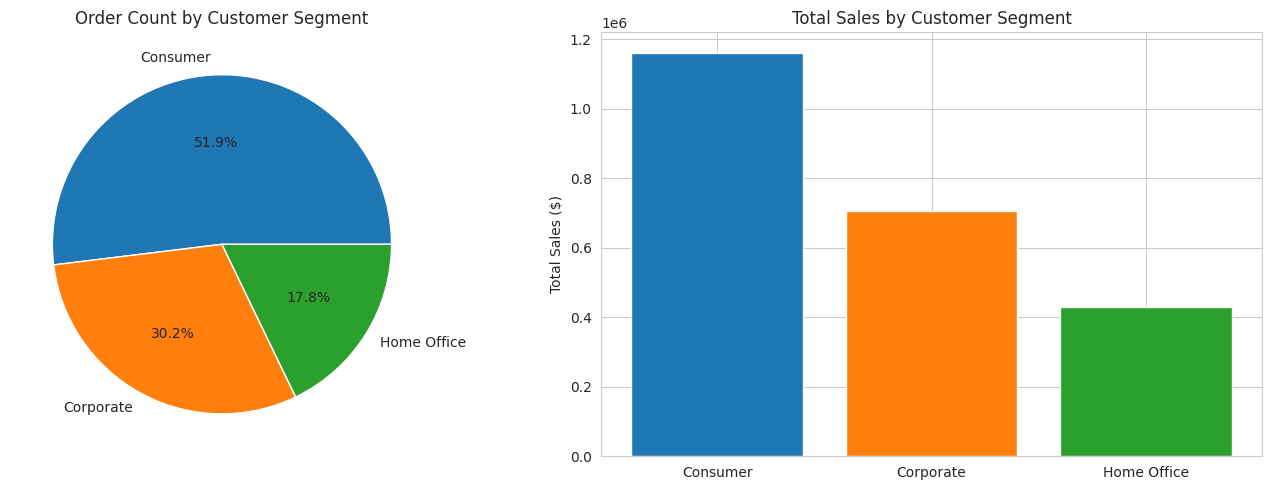

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


In [7]:
# Customer segment distribution
segment_counts = df['Segment'].value_counts()
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of orders per segment
axes[0].pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
            colors=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Order Count by Customer Segment')

# Sales by segment
axes[1].bar(segment_sales.index, segment_sales.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_title('Total Sales by Customer Segment')
axes[1].set_ylabel('Total Sales ($)')

plt.tight_layout()
plt.show()

print(segment_sales)

**Observation:** *(write your own take)*

The Consumer segment generates the largest share of both order volume and total sales, followed by Corporate and then Home Office. This suggests marketing and inventory decisions should weight most heavily toward individual consumer preferences, though Corporate remains a significant secondary segment worth retaining.

## Step 6: Product Analysis — Top 10 Best-Selling Products & Revenue by Category

Here we find which individual products sell the most (by total Sales value), and which product Category brings in the most revenue overall.

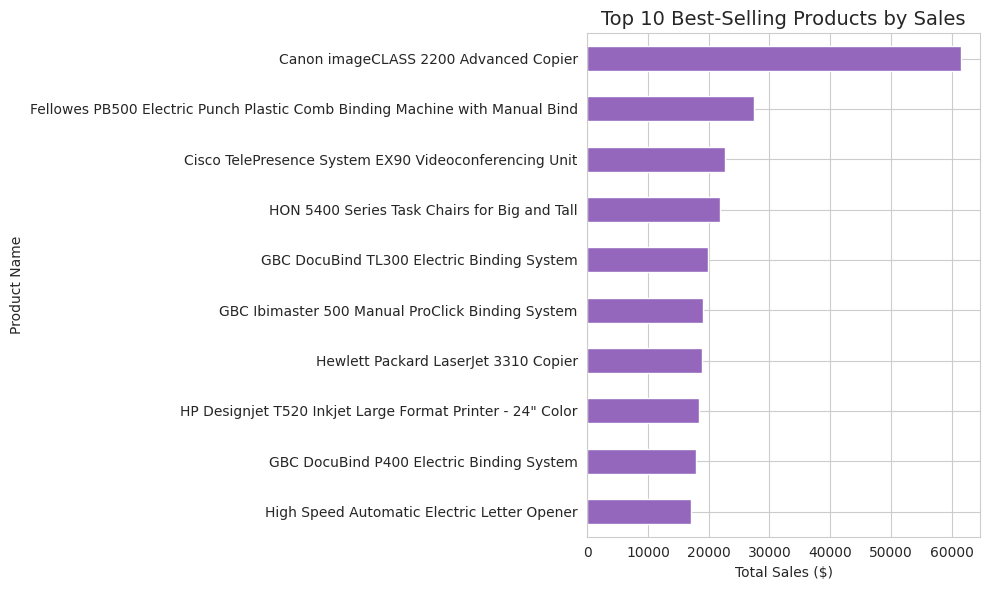

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [8]:
# Top 10 best-selling products by total sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh', color='#9467bd')
plt.title('Top 10 Best-Selling Products by Sales', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

print(top_products)

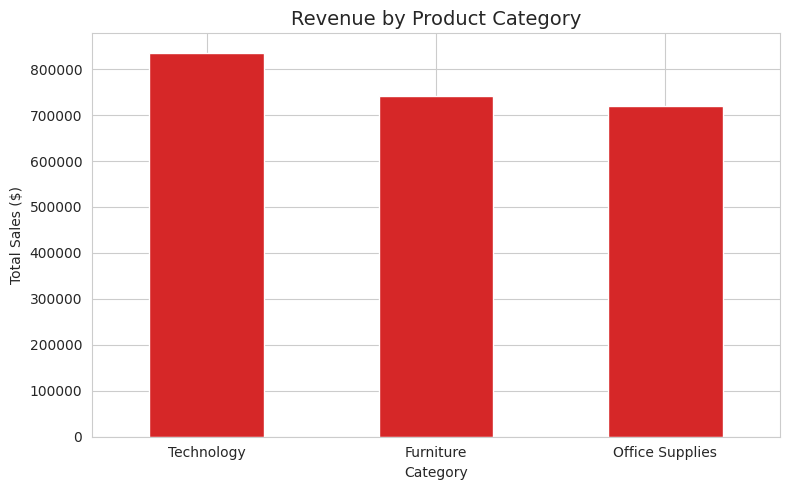

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [9]:
# Revenue by product category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', color='#d62728')
plt.title('Revenue by Product Category', fontsize=14)
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(category_sales)

**Observation:** *(write your own take)*

Technology and Furniture categories tend to dominate revenue due to higher price points per item, even though Office Supplies may have higher order volume. The top-selling individual products are often high-ticket items like copiers and specific furniture pieces — worth highlighting in promotions since they drive disproportionate revenue.

## Step 5: Customer Demographics Analysis

**Note:** This dataset doesn't include customer age or gender. As a substitute, we analyze the **Segment** column (Consumer / Corporate / Home Office), which is the closest available "customer type" breakdown. We also look at **Region** since that's another demographic-style split available in this data.

*(Mention this substitution clearly in your README/video — it shows you understood the checklist requirement and adapted sensibly when the exact field wasn't available.)*

Customer Segment distribution:
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64



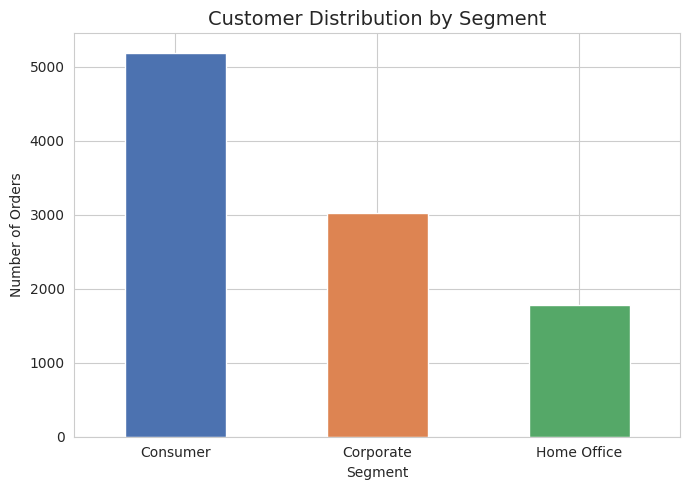

In [10]:
# Customer Segment distribution
segment_counts = df['Segment'].value_counts()
print("Customer Segment distribution:")
print(segment_counts)
print()

plt.figure(figsize=(7, 5))
segment_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Customer Distribution by Segment', fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

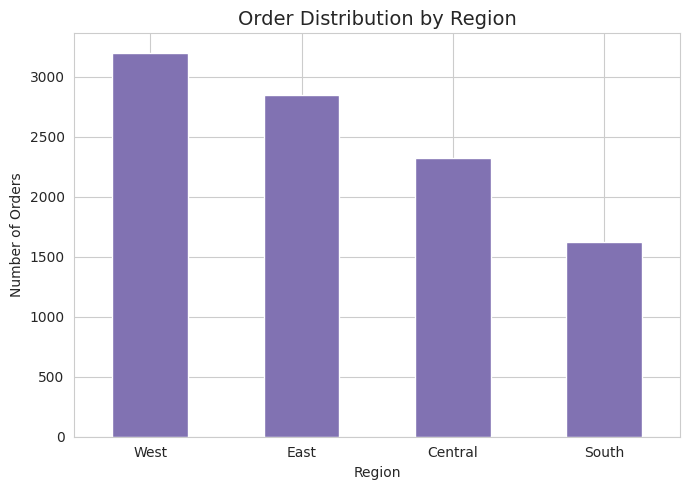

In [11]:
# Regional breakdown (as an additional demographic-style split)
region_counts = df['Region'].value_counts()

plt.figure(figsize=(7, 5))
region_counts.plot(kind='bar', color='#8172B2')
plt.title('Order Distribution by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** *(write your own take)*

The Consumer segment makes up the largest share of orders, followed by Corporate, then Home Office. Regionally, the West and East regions generate the most orders, while the South lags behind — this could point to weaker market penetration or fewer stores/marketing reach in that region.

## Step 6: Product Analysis

Now we find the top 10 best-selling products (by total Sales) and look at revenue by product Category.

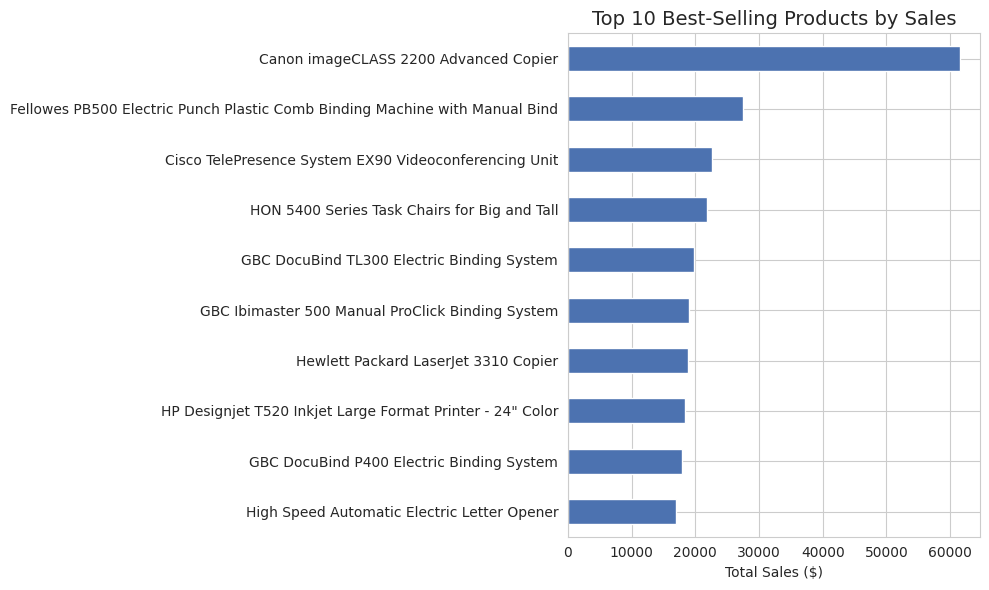

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [12]:
# Top 10 best-selling products by total sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Top 10 Best-Selling Products by Sales', fontsize=14)
plt.xlabel('Total Sales ($)')
plt.ylabel('')
plt.tight_layout()
plt.show()

print(top_products)

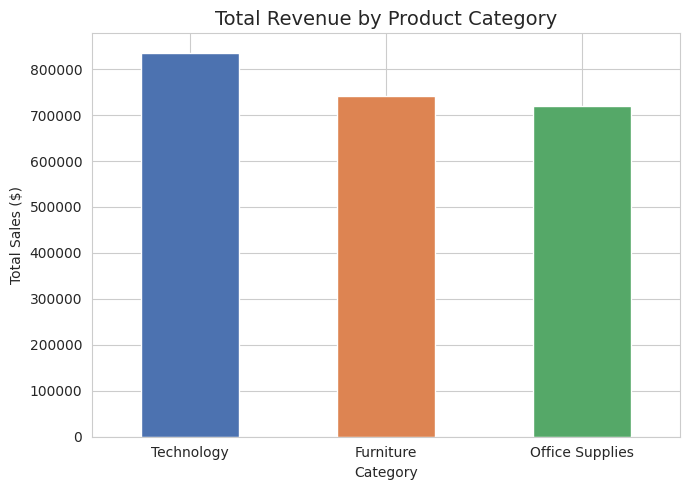

In [13]:
# Revenue by product category
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
category_revenue.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Total Revenue by Product Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** *(write your own take)*

Technology and Office Supplies tend to dominate the top 10 product list, particularly high-ticket items like copiers and phones. Category-wise, Technology usually generates the highest total revenue despite having fewer distinct products than Office Supplies — meaning individual Technology items sell at a higher price point.

## Step 7: Correlation Heatmap

We check how the numeric variables relate to each other — for example, does a higher Discount actually hurt Profit? A heatmap makes these relationships easy to see at a glance (values close to +1 = strong positive relationship, close to -1 = strong negative, close to 0 = no relationship).

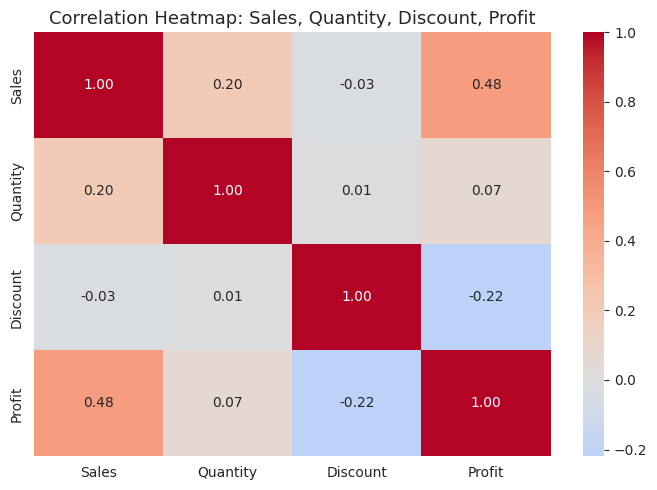

In [14]:
corr_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit', fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** *(write your own take)*

Discount shows a negative correlation with Profit — as discount increases, profit tends to drop, sometimes into losses. Sales and Profit have a positive but not perfect correlation, meaning high sales don't always guarantee high profit (a heavily discounted big sale can still lose money). Quantity has a weak relationship with Profit, suggesting profit is driven more by pricing/discounting than by order volume alone.

## Step 8: Extra Visualization — Discount vs. Profit (Non-Obvious Insight)

The correlation heatmap hinted that discounts hurt profit. Let's visualize this directly with a scatter plot to see *how* — is it a gradual decline, or is there a sharp cutoff where discounts start causing losses?

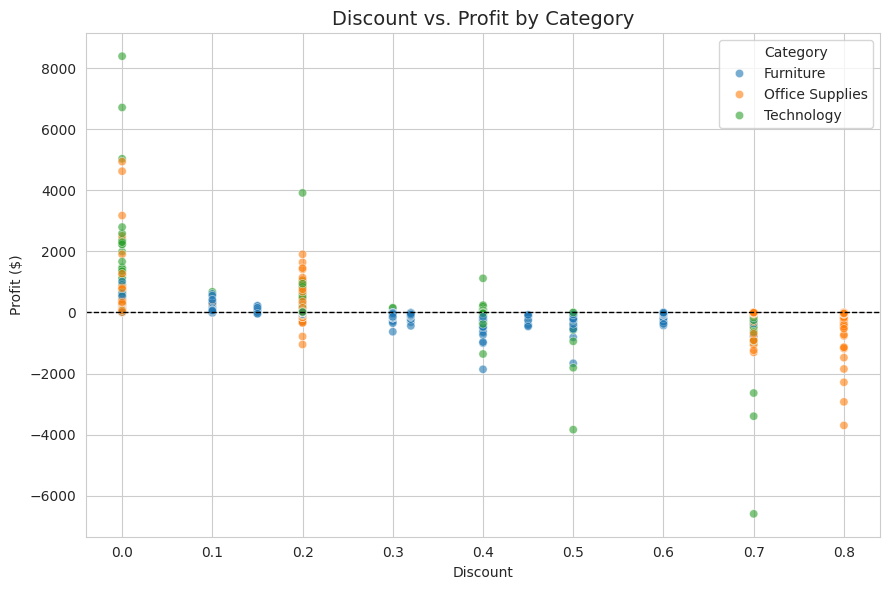

In [15]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Discount vs. Profit by Category', fontsize=14)
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

**Observation:** *(write your own take)*

There's a clear pattern: once discount goes above roughly 20-30%, most transactions fall below the \$0 profit line (the dashed line) — meaning the company is actively losing money on those orders. Furniture appears especially vulnerable to deep discounts turning unprofitable. This is a non-obvious insight because it's not visible from the correlation number alone — it shows there may be a specific discount threshold the business should avoid crossing.

## Step 9: Conclusion — Business Recommendations

*(This is a required section — write your own 3+ recommendations based on what you found. Below are starting points you can rewrite in your own words and expand on.)*

1. **Cap discounts on high-risk categories.** Since deep discounts (especially above ~20-30%) push many orders into a loss, especially in Furniture, the business should set a maximum discount threshold for these categories rather than allowing open-ended discounting.

2. **Double down on Q4 demand.** Sales consistently spike in Q4 (Nov-Dec). The business should ensure adequate inventory, staffing, and marketing spend is planned ahead of this period to capture the seasonal demand without stockouts.

3. **Investigate the South region's underperformance.** The South region generates noticeably fewer orders than West/East. This is worth investigating — it could indicate an opportunity for targeted marketing, more sales reps, or better logistics coverage in that region.

4. *(Optional 4th)* **Prioritize Technology category promotions.** Since Technology drives strong revenue per item, marketing spend aimed at this category may yield better returns than equivalent spend on lower-ticket categories.